In [1]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

import numpy as np
import scipy
import copy

from scipy.sparse import coo_matrix, block_diag, identity, hstack, csr_matrix, csc_matrix, vstack
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import time 

from pyiga import assemble, bspline, vform, geometry, vis, solvers, utils, topology, ieti, algebra, operators, adaptive
from pyiga import algebra_cy, ieti_cy, bspline_cy

from scipy.sparse.linalg import aslinearoperator as LinOp

np.set_printoptions(linewidth=100000)
np.set_printoptions(precision=5)

In [2]:
def LshapeAnullus(deg, N, k=1):
    kvs = 3*[2 * (bspline.make_knots(deg, 0.0, 1.0, N, mult=k),)]

    # define geometry
    geos = [
        geometry.annulus(r1=1.5, r2=2, phi = np.pi/4),
        geometry.annulus(r1=1.5, r2=2, phi = np.pi/4).rotate_2d(angle=np.pi/4),
        geometry.annulus(r1=1.0, r2=1.5, phi = np.pi/4).rotate_2d(angle=np.pi/4),
    ]

    patches = [(k, g) for k, g in zip(kvs,geos)]
    M = topology.MultiPatch(patches)
    M.outer_boundaries[0].add((1,(0,0)))
    return M

In [3]:
M = LshapeAnullus(1,2)

IMap = ieti.IetiMapper(M, dir_data={0:0}, subspace='C0', elim=1)

setting up constraints took 0.0019173622131347656 seconds.
Basis setup took 0.0012042522430419922 seconds


In [4]:
IMap.fixed_idx

{2: array([0, 1, 2, 4, 5, 6, 8]),
 0: array([0, 1, 2, 3, 5, 6, 8]),
 1: array([1, 2, 3, 4, 6, 8])}

In [5]:
A, RHS = IMap.assemble(a=1,f=1, M=None)
N = [A.shape[0] for A in A]

Prim, to_be_eliminated = IMap.nodes_as_primals(dir_boundary=False)

B, eliminated_constraints = IMap.ConstraintMatrices(eliminate=to_be_eliminated)
SD = ieti.ScaledDirichletPreconditioner(A, B, IMap)

nPrim=Prim.shape[1]
print(nPrim)

I = ieti.IetiSystem(A, B, RHS, N)
F, b = I.SchurComplement(), I.RHSforSchurComplement()
C = [scipy.sparse.csr_matrix((0,A[p].shape[1])) for p in range(len(B))]

lam, it, min_eig, max_eig, r = solvers.pcg(F, b, x0=None, maxiter=2000, P=1, output=1, rtol=1e-8, atol=1e-12)
uh = I.constructSolutionFromLagrangeMultipliers(lam)

if nPrim>0:
    uh = primal.distributePrimalSolution(uh)
uh = np.concatenate(IMap.completeDirichlet(uh))
if IMap.elim:
    uh = IMap.Basis_loc_global@uh


1
pcg with preconditioned condition number κ ~ 1.707 stopped after 8 iterations with relres 3.432e-09 after 0.00039 seconds.


NameError: name 'primal' is not defined

In [17]:
to_be_eliminated

array([ True, False, False,  True, False, False])

In [24]:
B[0].toarray()

array([[0., 0.],
       [0., 0.],
       [0., 0.],
       [0., 0.],
       [0., 1.],
       [0., 0.]])

In [26]:
IMap.B.toarray()

array([[ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0., -1.,  0.,  0.],
       [ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0., -1.,  0.],
       [ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0., -1.],
       [ 0.,  0.,  0.,  0.,  0.,  0.,  1.,  0.,  0.,  0.,  0.,  0.,  0., -1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.],
       [ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  1.,  0.,  0.,  0.,  0.,  0.,  0., -1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.],
       [ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  1.,  0.,  0.,  0.,  0.,  0.,  0., -1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.]])

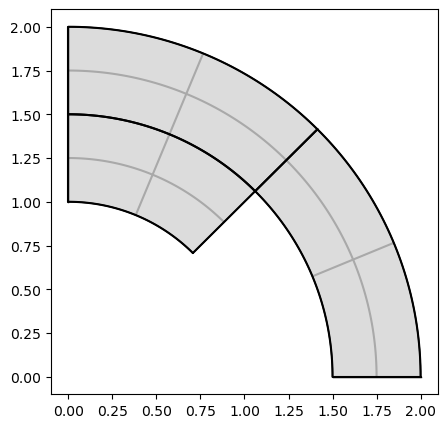

In [22]:
M.plotmesh(knots=1)